In [1]:
import glob, random, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

from google.colab import drive
import zipfile, os

In [40]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!cp "/content/drive/MyDrive/Deeplense/LF/dataset.zip" "/content/dataset.zip"

In [4]:
!unzip -q /content/dataset.zip -d /content/dataset_extracted

In [5]:
EXTRACT_DIR = '/content/dataset_extracted'

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

In [7]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [8]:
CFG = dict(
    train_lenses    = f'{EXTRACT_DIR}/train_lenses',
    train_nonlenses = f'{EXTRACT_DIR}/train_nonlenses',
    test_lenses     = f'{EXTRACT_DIR}/test_lenses',
    test_nonlenses  = f'{EXTRACT_DIR}/test_nonlenses',
    val_size        = 0.10,
    model_name      = 'resnet18',
    pretrained      = True,
    dropout         = 0.3,
    epochs          = 30,
    batch_size      = 64,
    lr              = 3e-4,
    weight_decay    = 1e-4,
    patience        = 7,
    save_path       = '/content/best_lens_model.pth',
)

In [9]:
def load_paths_and_labels(lens_dir, nonlens_dir):
    lens_files    = [f for f in glob.glob(os.path.join(lens_dir,    '*.npy'))
                     if not os.path.basename(f).startswith('._')]
    nonlens_files = [f for f in glob.glob(os.path.join(nonlens_dir, '*.npy'))
                     if not os.path.basename(f).startswith('._')]
    paths  = lens_files + nonlens_files
    labels = [1] * len(lens_files) + [0] * len(nonlens_files)
    return paths, labels

In [10]:
train_paths, train_labels = load_paths_and_labels(
    CFG['train_lenses'], CFG['train_nonlenses'])
test_paths, test_labels   = load_paths_and_labels(
    CFG['test_lenses'],  CFG['test_nonlenses'])

print(f"Train: {len(train_paths)} total  |  lenses: {sum(train_labels)}  |  non-lenses: {len(train_labels)-sum(train_labels)}")
print(f"Test : {len(test_paths)}  total  |  lenses: {sum(test_labels)}   |  non-lenses: {len(test_labels)-sum(test_labels)}")
ratio = (len(train_labels) - sum(train_labels)) / max(sum(train_labels), 1)
print(f"Imbalance ratio (non-lens:lens) = {ratio:.1f}:1")

Train: 30405 total  |  lenses: 1730  |  non-lenses: 28675
Test : 19650  total  |  lenses: 195   |  non-lenses: 19455
Imbalance ratio (non-lens:lens) = 16.6:1


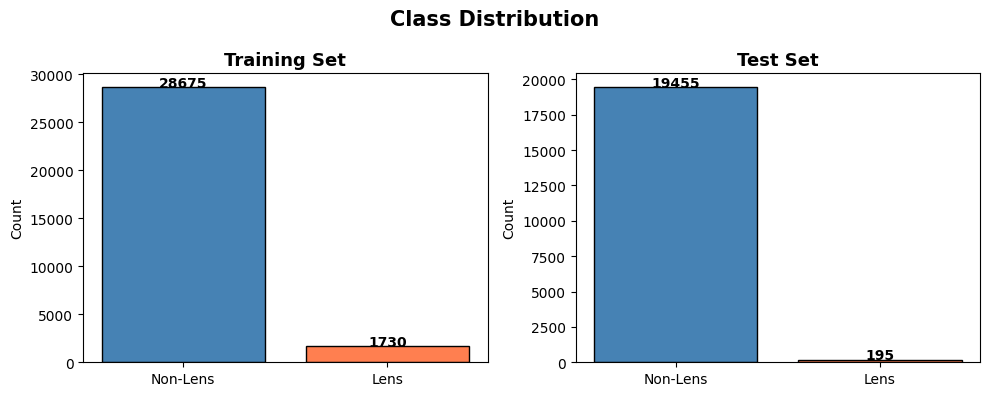

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (labels, title) in zip(axes, [
        (train_labels, 'Training Set'),
        (test_labels,  'Test Set')]):
    counts = Counter(labels)
    bars = ax.bar(['Non-Lens', 'Lens'], [counts[0], counts[1]],
                  color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, [counts[0], counts[1]]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
                ha='center', fontweight='bold')
plt.suptitle('Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [12]:
def show_samples(paths, labels, n=5, title='Samples'):
    lens_p    = [p for p, l in zip(paths, labels) if l == 1][:n]
    nonlens_p = [p for p, l in zip(paths, labels) if l == 0][:n]
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for row, (group, row_label) in enumerate([(lens_p, 'Lens'), (nonlens_p, 'Non-Lens')]):
        for col, path in enumerate(group):
            img = np.clip(np.transpose(np.load(path), (1, 2, 0)), 0, 1)
            axes[row, col].imshow(img)
            axes[row, col].set_title(f'{row_label}\n{Path(path).stem}', fontsize=8)
            axes[row, col].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

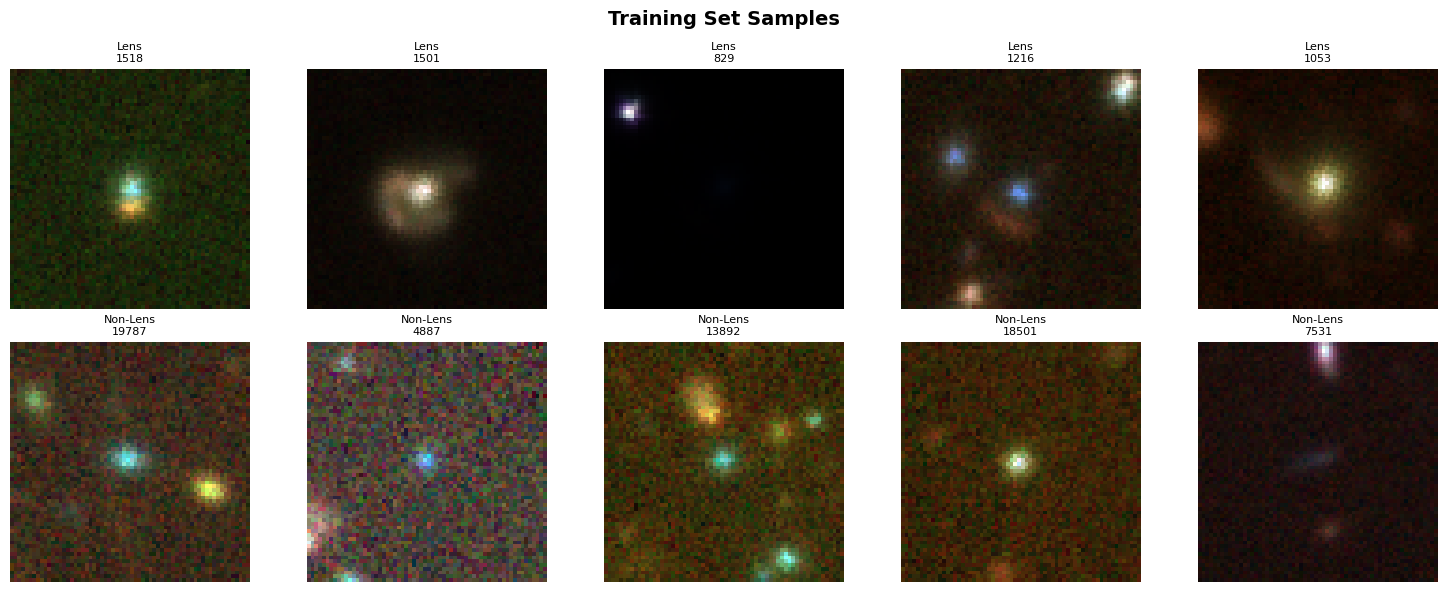

In [13]:
show_samples(train_paths, train_labels, n=5, title='Training Set Samples')

In [14]:
subset = random.sample(train_paths, min(500, len(train_paths)))
means, stds = [], []
for p in subset:
    img = np.load(p).astype(np.float32)
    means.append(img.mean(axis=(1, 2)))
    stds.append(img.std(axis=(1, 2)))

MEAN = torch.tensor(np.stack(means).mean(axis=0), dtype=torch.float32)
STD  = torch.tensor(np.stack(stds).mean(axis=0),  dtype=torch.float32)
print(f'Channel means: {MEAN.numpy()}')
print(f'Channel stds : {STD.numpy()}')

Channel means: [0.27606648 0.19510724 0.10936976]
Channel stds : [0.09682626 0.08253094 0.06347582]


In [15]:
train_tf = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=180),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.Normalize(mean=MEAN, std=STD),
])

val_tf = T.Compose([
    T.Normalize(mean=MEAN, std=STD),
])

In [16]:
class LensDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = torch.from_numpy(np.load(self.paths[idx]).astype(np.float32))
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, label

In [17]:
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=CFG['val_size'], stratify=train_labels, random_state=SEED
)

print(f"Train split : {len(tr_paths)}   lenses={sum(tr_labels)}  non-lenses={len(tr_labels)-sum(tr_labels)}")
print(f"Val   split : {len(val_paths)}  lenses={sum(val_labels)} non-lenses={len(val_labels)-sum(val_labels)}")

Train split : 27364   lenses=1557  non-lenses=25807
Val   split : 3041  lenses=173 non-lenses=2868


In [18]:
class_counts   = Counter(tr_labels)
sample_weights = [1.0 / class_counts[l] for l in tr_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

In [19]:
train_ds = LensDataset(tr_paths,   tr_labels,   transform=train_tf)
val_ds   = LensDataset(val_paths,  val_labels,  transform=val_tf)
test_ds  = LensDataset(test_paths, test_labels, transform=val_tf)

In [20]:
train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                          shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False,    num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 428 | Val batches: 48 | Test batches: 308


In [21]:
class LensClassifier(nn.Module):
    def __init__(self, model_name='efficientnet_b0', pretrained=True, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained, num_classes=0, in_chans=3)
        nf = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(nf, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)

In [22]:
model = LensClassifier(
    model_name=CFG['model_name'],
    pretrained=CFG['pretrained'],
    dropout=CFG['dropout'],
).to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [23]:
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')

Total parameters    : 11,308,609
Trainable parameters: 11,308,609


In [24]:
n_neg = class_counts[0]
n_pos = class_counts[1]
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f'pos_weight = {pos_weight.item():.2f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimiser = optim.AdamW(
    model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=CFG['epochs'], eta_min=1e-6)

pos_weight = 16.57


In [25]:
def run_epoch(model, loader, criterion, optimiser=None):
    is_train = optimiser is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if is_train:
                optimiser.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimiser.step()
            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss   = total_loss / len(loader.dataset)
    epoch_auc  = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5
    return avg_loss, epoch_auc

In [26]:
history        = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
best_val_auc   = 0.0
patience_count = 0

header = f"{'Epoch':>5} | {'Train Loss':>10} | {'Train AUC':>9} | {'Val Loss':>9} | {'Val AUC':>8} | {'LR':>9}"
print(header)
print('-' * len(header))

for epoch in range(1, CFG['epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_auc = run_epoch(model, train_loader, criterion, optimiser)
    va_loss, va_auc = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(va_auc)

    lr_now = scheduler.get_last_lr()[0]
    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_auc:>9.4f} | {va_loss:>9.4f} | {va_auc:>8.4f} | {lr_now:.2e}  ({time.time()-t0:.1f}s)")

    if va_auc > best_val_auc:
        best_val_auc   = va_auc
        patience_count = 0
        torch.save(model.state_dict(), CFG['save_path'])
        print(f"       ✓ New best val AUC: {best_val_auc:.4f} — saved.")
    else:
        patience_count += 1
        if patience_count >= CFG['patience']:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f'\nBest Validation AUC: {best_val_auc:.4f}')

Epoch | Train Loss | Train AUC |  Val Loss |  Val AUC |        LR
-----------------------------------------------------------------
    1 |     0.9950 |    0.9481 |    0.6299 |   0.9734 | 2.99e-04  (57.2s)
       ✓ New best val AUC: 0.9734 — saved.
    2 |     0.6181 |    0.9759 |    0.4577 |   0.9850 | 2.97e-04  (52.9s)
       ✓ New best val AUC: 0.9850 — saved.
    3 |     0.5299 |    0.9823 |    0.4693 |   0.9812 | 2.93e-04  (53.3s)
    4 |     0.4967 |    0.9848 |    0.2846 |   0.9885 | 2.87e-04  (51.4s)
       ✓ New best val AUC: 0.9885 — saved.
    5 |     0.4394 |    0.9865 |    0.3570 |   0.9898 | 2.80e-04  (52.2s)
       ✓ New best val AUC: 0.9898 — saved.
    6 |     0.4319 |    0.9877 |    0.4678 |   0.9888 | 2.71e-04  (50.6s)
    7 |     0.3954 |    0.9900 |    0.3351 |   0.9908 | 2.62e-04  (51.4s)
       ✓ New best val AUC: 0.9908 — saved.
    8 |     0.3785 |    0.9901 |    0.2738 |   0.9920 | 2.51e-04  (50.6s)
       ✓ New best val AUC: 0.9920 — saved.
    9 |     0.3716

KeyboardInterrupt: 

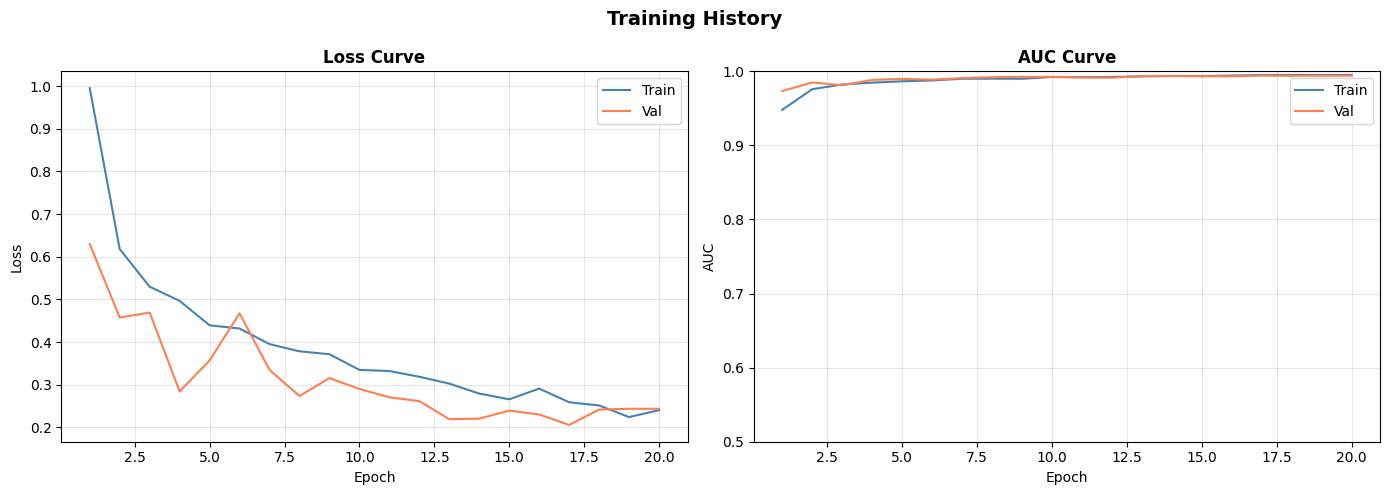

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='coral')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_auc'], label='Train', color='steelblue')
axes[1].plot(ep, history['val_auc'],   label='Val',   color='coral')
axes[1].set_title('AUC Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
model.load_state_dict(torch.load(CFG['save_path'], map_location=DEVICE))
model.eval()

LensClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act1): ReLU(inplace=True)
        (aa): Identity()
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act2): ReLU(inplace=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), paddi

In [29]:
def predict(model, loader):
    all_labels, all_probs = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_probs)

In [30]:
val_labels_arr,  val_probs  = predict(model, val_loader)
test_labels_arr, test_probs = predict(model, test_loader)
print('Predictions done.')

Predictions done.


In [31]:
val_fpr,  val_tpr,  val_thresholds  = roc_curve(val_labels_arr,  val_probs)
test_fpr, test_tpr, test_thresholds = roc_curve(test_labels_arr, test_probs)
val_auc_score  = auc(val_fpr,  val_tpr)
test_auc_score = auc(test_fpr, test_tpr)

print(f'Validation AUC : {val_auc_score:.4f}')
print(f'Test       AUC : {test_auc_score:.4f}')

Validation AUC : 0.9943
Test       AUC : 0.9814


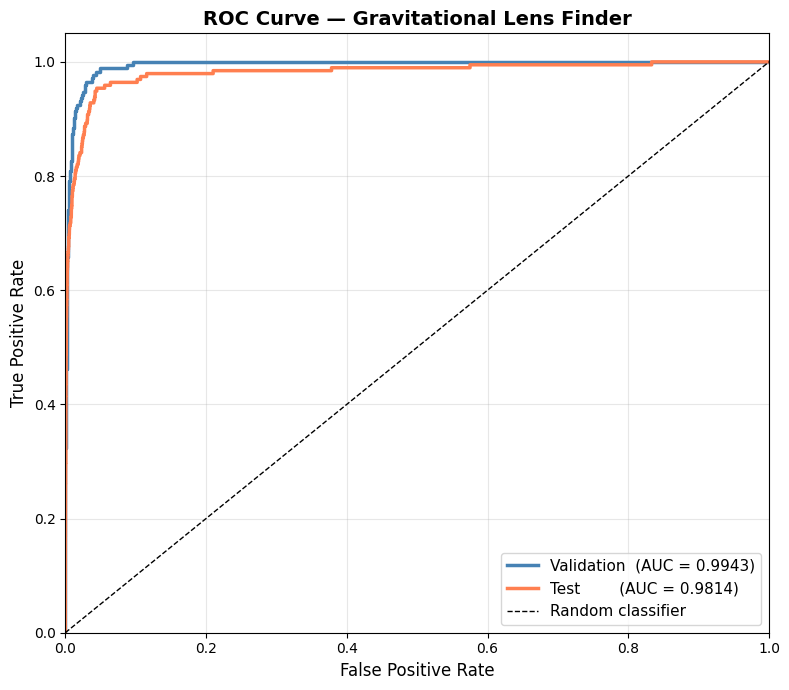

Saved: /content/roc_curve.png


In [32]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(val_fpr,  val_tpr,  color='steelblue', lw=2.5,
        label=f'Validation  (AUC = {val_auc_score:.4f})')
ax.plot(test_fpr, test_tpr, color='coral',     lw=2.5,
        label=f'Test        (AUC = {test_auc_score:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — Gravitational Lens Finder', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: /content/roc_curve.png')

In [33]:
j_scores = val_tpr - val_fpr
opt_idx   = np.argmax(j_scores)
opt_thresh = val_thresholds[opt_idx]
print(f"Optimal threshold (Youden J): {opt_thresh:.4f}")
print(f"At this threshold — TPR: {val_tpr[opt_idx]:.4f}  FPR: {val_fpr[opt_idx]:.4f}")

Optimal threshold (Youden J): 0.5359
At this threshold — TPR: 0.9884  FPR: 0.0492


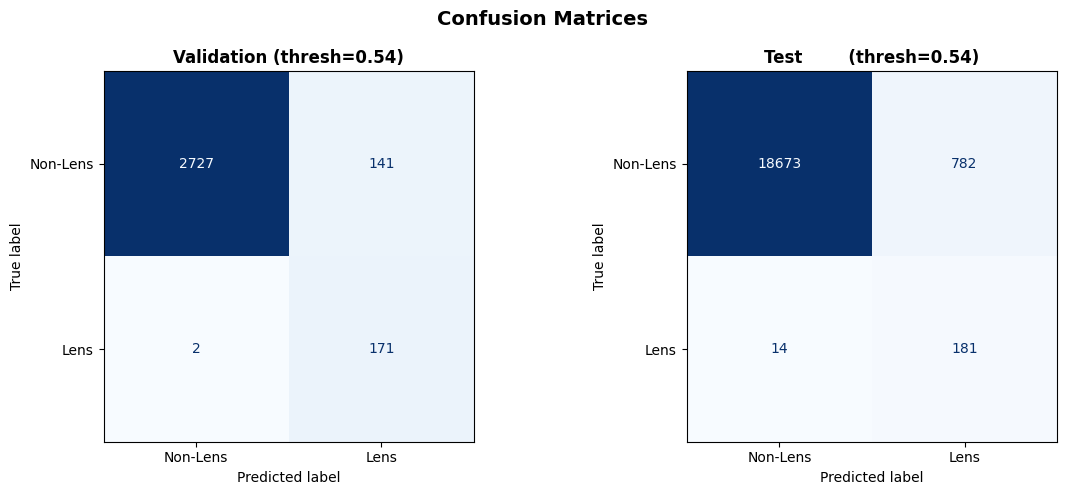

In [34]:
val_preds  = (val_probs  >= opt_thresh).astype(int)
test_preds = (test_probs >= opt_thresh).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (preds, labels_arr, title) in zip(axes, [
        (val_preds,  val_labels_arr,  f'Validation (thresh={opt_thresh:.2f})'),
        (test_preds, test_labels_arr, f'Test        (thresh={opt_thresh:.2f})'),
    ]):
    cm = confusion_matrix(labels_arr, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Non-Lens', 'Lens']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
print('=' * 55)
print('VALIDATION SET — Classification Report')
print('=' * 55)
print(classification_report(val_labels_arr,  val_preds,
                             target_names=['Non-Lens','Lens'], digits=4))

print('=' * 55)
print('TEST SET — Classification Report')
print('=' * 55)
print(classification_report(test_labels_arr, test_preds,
                             target_names=['Non-Lens','Lens'], digits=4))

VALIDATION SET — Classification Report
              precision    recall  f1-score   support

    Non-Lens     0.9993    0.9508    0.9745      2868
        Lens     0.5481    0.9884    0.7052       173

    accuracy                         0.9530      3041
   macro avg     0.7737    0.9696    0.8398      3041
weighted avg     0.9736    0.9530    0.9591      3041

TEST SET — Classification Report
              precision    recall  f1-score   support

    Non-Lens     0.9993    0.9598    0.9791     19455
        Lens     0.1880    0.9282    0.3126       195

    accuracy                         0.9595     19650
   macro avg     0.5936    0.9440    0.6459     19650
weighted avg     0.9912    0.9595    0.9725     19650



In [36]:
print(f"\n{'Metric':<12}  {'Validation':>12}  {'Test':>12}")
print('-' * 40)
for metric, fn in [
    ('AUC',       roc_auc_score),
    ('Precision', lambda y,p: precision_score(y,p)),
    ('Recall',    lambda y,p: recall_score(y,p)),
    ('F1',        lambda y,p: f1_score(y,p)),
]:
    if metric == 'AUC':
        v_score = fn(val_labels_arr,  val_probs)
        t_score = fn(test_labels_arr, test_probs)
    else:
        v_score = fn(val_labels_arr,  val_preds)
        t_score = fn(test_labels_arr, test_preds)
    print(f"{metric:<12}  {v_score:>12.4f}  {t_score:>12.4f}")


Metric          Validation          Test
----------------------------------------
AUC                 0.9943        0.9814
Precision           0.5481        0.1880
Recall              0.9884        0.9282
F1                  0.7052        0.3126


In [37]:
def show_prediction_grid(paths, labels_arr, probs, threshold, n=4, title=''):
    preds = (probs >= threshold).astype(int)
    tp = [i for i in range(len(labels_arr)) if labels_arr[i]==1 and preds[i]==1][:n]
    fn = [i for i in range(len(labels_arr)) if labels_arr[i]==1 and preds[i]==0][:n]
    fp = [i for i in range(len(labels_arr)) if labels_arr[i]==0 and preds[i]==1][:n]

    row_meta = [
        ('Correctly found lenses (TP)', tp, 'green'),
        ('Missed lenses — False Neg (FN)', fn, 'red'),
        ('False Positives (FP)', fp, 'orange'),
    ]
    fig, axes = plt.subplots(3, n, figsize=(3*n, 9))
    for row_idx, (row_title, indices, color) in enumerate(row_meta):
        for col_idx in range(n):
            ax = axes[row_idx, col_idx]
            if col_idx < len(indices):
                img = np.clip(np.transpose(np.load(paths[indices[col_idx]]), (1,2,0)), 0, 1)
                ax.imshow(img)
                ax.set_title(f"p={probs[indices[col_idx]]:.3f}", fontsize=9, color=color)
            ax.axis('off')
        axes[row_idx, 0].set_ylabel(row_title, fontsize=9, color=color,
                                     fontweight='bold', rotation=90, labelpad=45)
    plt.suptitle(f'{title} — Predictions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

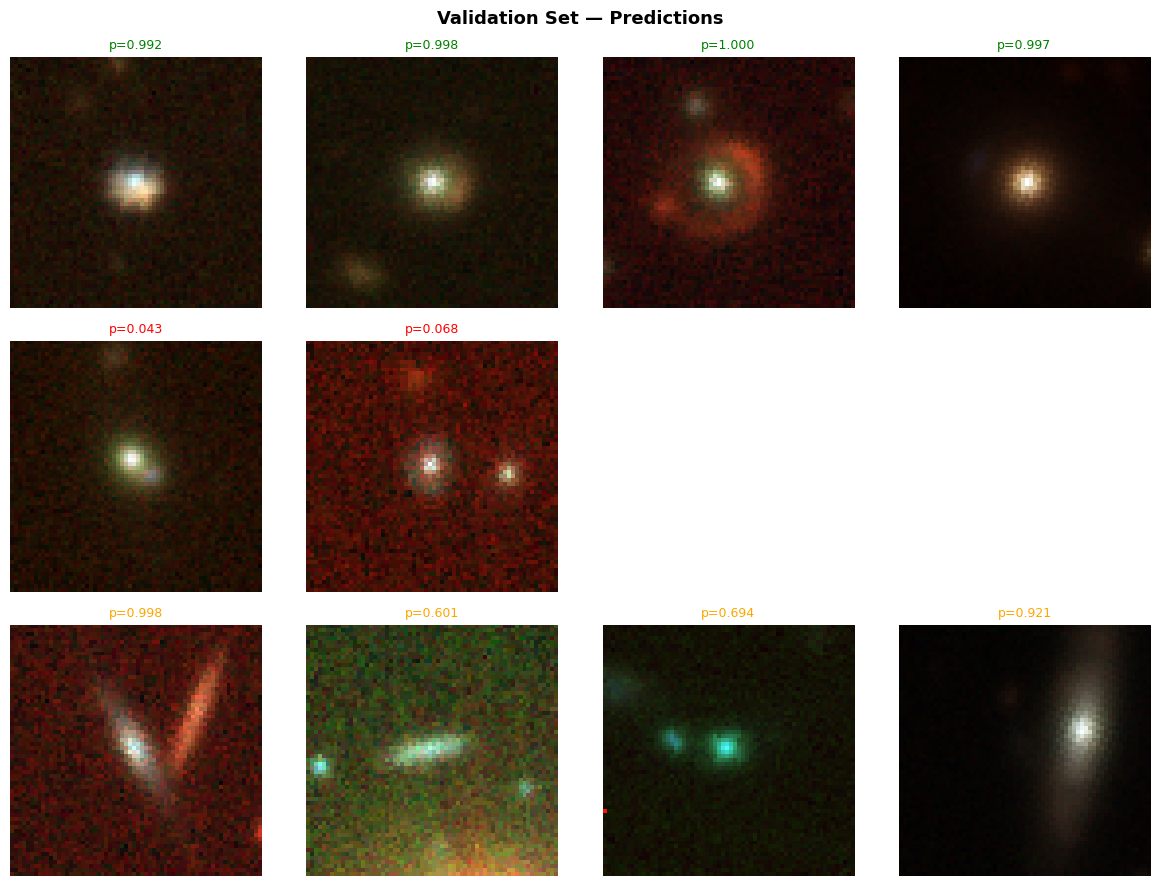

In [38]:
show_prediction_grid(val_paths, val_labels_arr, val_probs,
                     opt_thresh, n=4, title='Validation Set')

In [42]:
import shutil

drive_model_path = '/content/drive/MyDrive/lens_finder_best_model.pth'
shutil.copy(CFG['save_path'], drive_model_path)
print(f'Model saved to Drive: {drive_model_path}')

np.save('/content/drive/MyDrive/val_probs.npy',    val_probs)
np.save('/content/drive/MyDrive/test_probs.npy',   test_probs)
np.save('/content/drive/MyDrive/val_labels.npy',   val_labels_arr)
np.save('/content/drive/MyDrive/test_labels.npy',  test_labels_arr)

print('All artefacts saved.')
print('  - lens_finder_best_model.pth')
print('  - /content/roc_curve.png')
print('  - /content/confusion_matrix.png')
print('  - /content/training_curves.png')

Model saved to Drive: /content/drive/MyDrive/Deeplense/LF/resnet18
All artefacts saved.
  - lens_finder_best_model.pth
  - /content/roc_curve.png
  - /content/confusion_matrix.png
  - /content/training_curves.png
